<a href="https://colab.research.google.com/github/ai-agent-yonsei/agent/blob/main/3_3_Replanning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Routing → Planning → Replanning (with LangGraph)
**OpenAI API 하나만 사용**하여  
`Routing → Planning → Execution Feedback → Replanning → Final Action` 흐름을 구현

In [1]:
# ============================================================
# 1. 패키지 설치
# ============================================================
!pip -q install -U langgraph langchain-openai networkx matplotlib pandas

# 한글 폰트
!apt-get -qq update
!apt-get -qq install -y fonts-noto-cjk > /dev/null

print("패키지 및 한글 폰트 설치 완료")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 80.3/80.3 kB 7.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.5/79.5 kB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 125.8/125.8 kB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 159.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.9/10.9 MB 147.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 571.8/571.8 kB 51.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-colab 1.0.0 requires pandas==2.2.3, but you have pandas 3.0.5 which is incompatible.
dask-cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
cudf-cu12 26.2.1 requires pandas<2.4.0,>=2.0, but you have pandas 3.0.5 which is incompatible.
W: https://developer.download.nvidia.com/compute/cuda/repo

In [2]:
# ============================================================
# 2. Import + 한글 폰트 설정
# ============================================================
import os
import json
import re
from typing import TypedDict, Literal, List, Dict, Any, Optional

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import networkx as nx

from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI

font_paths = [
    "/usr/share/fonts/opentype/noto/NotoSansCJK-Regular.ttc",
    "/usr/share/fonts/opentype/noto/NotoSansCJKkr-Regular.otf",
]

font_path = next((p for p in font_paths if os.path.exists(p)), None)

if font_path:
    fm.fontManager.addfont(font_path)
    font_prop = fm.FontProperties(fname=font_path)
    plt.rcParams["font.family"] = font_prop.get_name()
    print("한글 폰트:", font_prop.get_name())
else:
    candidates = [f for f in fm.fontManager.ttflist if "Noto Sans CJK" in f.name]
    if candidates:
        plt.rcParams["font.family"] = candidates[0].name
        print("한글 폰트:", candidates[0].name)
    else:
        print("Noto Sans CJK를 찾지 못했습니다.")

plt.rcParams["axes.unicode_minus"] = False

한글 폰트: Noto Sans CJK JP


In [3]:
# ============================================================
# 3. OpenAI API Key — Google Colab Secrets
# ============================================================

from google.colab import userdata

OPENAI_API_KEY = userdata.get("OPENAI_API_KEY")

if not OPENAI_API_KEY:
    raise ValueError(
        "Colab Secrets에 OPENAI_API_KEY가 없습니다. "
        "왼쪽 Secrets에서 OPENAI_API_KEY를 먼저 등록"
    )

os.environ["OPENAI_API_KEY"] = OPENAI_API_KEY

print("OPENAI_API_KEY loaded from Google Colab Secrets")

OPENAI_API_KEY loaded from Google Colab Secrets


## Routing Strategy

Router는 요청의 성격에 따라 다음 전략 중 하나를 선택함

| Strategy | 의미 |
|---|---|
| `general` | 일반 업무 / 분석 |
| `document` | 긴 문서 / 정책 / 요구사항 |
| `search_travel` | 검색 / 지도 / 여행 |
| `local_model` | 오픈소스 / 로컬 모델 / GPU 제약 |

예:

```text
selected_strategy = document
executed_model    = openai
```

**Routing은 모델 선택이 아니라 처리 전략 선택**

In [4]:
# ============================================================
# 4. State 정의
# ============================================================
Strategy = Literal["general", "document", "search_travel", "local_model"]

class AgentState(TypedDict, total=False):
    user_request: str

    selected_strategy: Strategy
    executed_model: str

    initial_plan: List[str]
    execution_feedback: str
    need_replan: bool
    revised_plan: List[str]

    final_answer: str
    path: List[str]
    event_log: List[Dict[str, Any]]

In [5]:
# ============================================================
# 5. 공통 함수
# ============================================================
def append_trace(
    state: AgentState,
    node: str,
    stage: str,
    detail: str,
    provider: Optional[str] = None,
):
    """노드 실행 기록을 state에 누적합니다."""
    path = list(state.get("path", []))
    path.append(node)

    event_log = list(state.get("event_log", []))
    event_log.append({
        "step": len(event_log) + 1,
        "node": node,
        "stage": stage,
        "provider": provider or "-",
        "detail": detail,
    })

    return {"path": path, "event_log": event_log}


def parse_json_safely(text: str):
    """```json ...``` 형태가 와도 JSON 부분만 추출합니다."""
    text = text.strip()
    text = re.sub(r"^```(?:json)?\\s*", "", text)
    text = re.sub(r"\\s*```$", "", text)
    m = re.search(r"\\{.*\\}", text, re.DOTALL)
    if m:
        text = m.group(0)
    return json.loads(text)


def normalize_plan(plan):
    """plan을 항상 문자열 리스트 형태로 정규화합니다."""
    if isinstance(plan, list):
        return [str(x).strip() for x in plan if str(x).strip()]
    if isinstance(plan, str):
        lines = [
            re.sub(r"^\\s*[\\d\\-\\.\\)\\(]+\\s*", "", x).strip()
            for x in plan.splitlines()
        ]
        return [x for x in lines if x]
    return [str(plan)]

In [6]:
# ============================================================
# 6. OpenAI Model
# ============================================================
# 이번 실습에서 사용하는 유일한 LLM

llm = ChatOpenAI(
    model="gpt-5.4-mini",
    temperature=0,
)

print("OpenAI model initialized")

OpenAI model initialized


In [7]:
# ============================================================
# 7. Routing
# ============================================================
def router_node(state: AgentState):
    q = state["user_request"].lower()

    if any(k in q for k in ["오픈소스", "로컬 모델", "hugging", "허깅페이스", "gpu"]):
        strategy: Strategy = "local_model"
    elif any(k in q for k in ["google", "구글", "지도", "검색", "여행", "장소"]):
        strategy = "search_travel"
    elif any(k in q for k in ["긴 문서", "정책", "계약서", "요구사항", "문서"]):
        strategy = "document"
    else:
        strategy = "general"

    trace = append_trace(
        state,
        node="router",
        stage="Routing",
        detail=f"요청 특성을 분석하여 {strategy} 전략 선택",
        provider="openai",
    )

    return {
        "selected_strategy": strategy,
        "executed_model": "openai",
        **trace,
    }

def route_after_router(state: AgentState):
    return state["selected_strategy"]

In [8]:
# ============================================================
# 8. Strategy별 Planning
# ============================================================
PLANNER_PERSONA = {
    "general": '''
당신은 범용 업무 에이전트 planner입니다.
목표를 3~5개의 실행 가능한 단계로 분해하고
의존성, 시간, 비용 제약을 고려하세요.
''',
    "document": '''
당신은 긴 문서/정책/복잡한 요구사항을 구조화하는 planner입니다.
불확실한 조건과 요구사항 충돌을 먼저 고려하여
3~5개의 실행 단계로 만드세요.
''',
    "search_travel": '''
당신은 검색/지도/외부 최신정보 활용을 고려하는 planner입니다.
외부 정보 확인이 필요한 지점을 구분하여
3~5개의 실행 단계로 만드세요.
''',
    "local_model": '''
당신은 오픈소스/로컬 모델 환경을 고려하는 planner입니다.
GPU, 모델 크기, 라이선스, 실행환경을 고려하여
3~5개의 현실적인 실행 단계로 만드세요.
''',
}

def make_planner_node(strategy: Strategy):
    def planner_node(state: AgentState):
        prompt = f'''
{PLANNER_PERSONA[strategy]}

사용자 요청:
{state["user_request"]}

아래 JSON 형식만 출력하세요.

{{
  "plan": [
    "1단계",
    "2단계",
    "3단계"
  ]
}}
'''
        response = llm.invoke(prompt)
        parsed = parse_json_safely(response.content)
        plan = normalize_plan(parsed["plan"])

        trace = append_trace(
            state,
            node=f"plan_{strategy}",
            stage="Planning",
            detail=f"{strategy} 전략으로 최초 계획 {len(plan)}단계 생성",
            provider="openai",
        )

        return {
            "initial_plan": plan,
            "executed_model": "openai",
            **trace,
        }

    return planner_node

plan_general = make_planner_node("general")
plan_document = make_planner_node("document")
plan_search_travel = make_planner_node("search_travel")
plan_local_model = make_planner_node("local_model")

## Execution Feedback가 필요한 이유

Replanning은 단순히 Planning을 두 번 실행하는 것이 아닌
첫 계획을 실행하는 과정에서 다음처럼 **새로운 Observation / State / Constraint**가 생겼을 때 의미가 있음

- Tool 실행 실패
- 일정/예약 상황 변화
- 예산 초과
- 요구사항 충돌 발견
- API 오류
- 데이터 없음
- GPU 메모리 부족

이 실습에서는 외부 서비스 없이 반복 실행이 가능하도록 **재현 가능한 feedback을 코드로 생성** 함

In [9]:
# ============================================================
# 9. Execution Feedback
# ============================================================
def execution_feedback_node(state: AgentState):
    q = state["user_request"].lower()

    if any(k in q for k in ["여행", "지도", "검색", "구글"]):
        feedback = (
            "실행 중 확인 결과 첫 번째 후보 장소가 해당 시간에 운영하지 않는 것으로 확인되었습니다. "
            "대체 장소와 이동 순서를 다시 계획해야 합니다."
        )
        need_replan = True

    elif any(k in q for k in ["오픈소스", "로컬 모델", "hugging", "허깅페이스"]):
        feedback = (
            "실행 환경의 GPU 메모리가 예상보다 작아 최초 선정 모델을 로드할 수 없습니다. "
            "더 작은 모델 또는 양자화 전략으로 수정해야 합니다."
        )
        need_replan = True

    elif any(k in q for k in ["긴 문서", "정책", "계약서", "요구사항"]):
        feedback = (
            "문서 검토 중 핵심 요구사항 하나가 최초 계획의 가정과 충돌하는 것이 발견되었습니다. "
            "요구사항 우선순위와 검토 순서를 수정해야 합니다."
        )
        need_replan = True

    elif any(k in q for k in ["예산", "비용", "만원", "달러"]):
        feedback = (
            "최초 계획을 그대로 실행할 경우 예상 비용이 사용자의 예산을 초과합니다. "
            "비용 제약을 만족하도록 계획을 수정해야 합니다."
        )
        need_replan = True

    else:
        feedback = (
            "실행 점검 결과 기존 계획을 그대로 수행할 수 있으며 "
            "추가적인 장애나 조건 변화가 없습니다."
        )
        need_replan = False

    trace = append_trace(
        state,
        node="execution_feedback",
        stage="Execution / Observation",
        detail=feedback,
        provider="openai",
    )

    return {
        "execution_feedback": feedback,
        "need_replan": need_replan,
        **trace,
    }

In [10]:
# ============================================================
# 10. Replan Gate
# ============================================================
def replan_gate_node(state: AgentState):
    detail = (
        "기존 계획이 더 이상 유효하지 않음 → Replanning 수행"
        if state["need_replan"]
        else
        "기존 계획이 여전히 유효함 → Replanning 생략"
    )

    return append_trace(
        state,
        node="replan_gate",
        stage="Replanning Decision",
        detail=detail,
        provider="openai",
    )

def route_after_replan_gate(state: AgentState):
    if not state["need_replan"]:
        return "no_replan"
    return state["selected_strategy"]

In [11]:
# ============================================================
# 11. Strategy별 Replanning
# ============================================================
REPLANNER_PERSONA = {
    "general": '''
당신은 범용 업무 에이전트 replanner입니다.
최초 계획을 전부 버리지 말고, 새 피드백 때문에 문제가 생긴 부분을 우선 수정하세요.
''',
    "document": '''
당신은 문서/정책/요구사항 작업 replanner입니다.
새롭게 발견된 충돌 조건을 반영하고,
유지할 단계와 수정할 단계를 구분하세요.
''',
    "search_travel": '''
당신은 검색/지도/외부 정보 변화에 대응하는 replanner입니다.
새로운 관찰 결과를 반영하여 대체 옵션과 순서를 수정하세요.
''',
    "local_model": '''
당신은 오픈소스/로컬 환경 replanner입니다.
실행 자원 제약을 반영하여 모델 크기, 양자화, 런타임 전략을 수정하세요.
''',
}

def make_replanner_node(strategy: Strategy):
    def replanner_node(state: AgentState):
        prompt = f'''
{REPLANNER_PERSONA[strategy]}

[원래 요청]
{state["user_request"]}

[최초 계획]
{json.dumps(state["initial_plan"], ensure_ascii=False, indent=2)}

[새롭게 관찰된 실행 피드백]
{state["execution_feedback"]}

요구사항:
1. 유지 가능한 기존 단계는 최대한 유지합니다.
2. 실패 원인 또는 환경 변화를 직접 반영합니다.
3. 수정된 계획은 3~5단계로 작성합니다.
4. 무엇을 왜 바꿨는지 한 문장으로 정리합니다.

아래 JSON만 출력하세요.

{{
  "revised_plan": [
    "수정 1단계",
    "수정 2단계",
    "수정 3단계"
  ],
  "change_summary": "변경 이유"
}}
'''
        response = llm.invoke(prompt)
        parsed = parse_json_safely(response.content)

        revised_plan = normalize_plan(parsed["revised_plan"])
        change_summary = parsed.get("change_summary", "실행 피드백 반영")

        trace = append_trace(
            state,
            node=f"replan_{strategy}",
            stage="Replanning",
            detail=change_summary,
            provider="openai",
        )

        return {
            "revised_plan": revised_plan,
            "executed_model": "openai",
            **trace,
        }

    return replanner_node

replan_general = make_replanner_node("general")
replan_document = make_replanner_node("document")
replan_search_travel = make_replanner_node("search_travel")
replan_local_model = make_replanner_node("local_model")

In [12]:
# ============================================================
# 12. Replanning이 필요 없는 경우
# ============================================================
def no_replan_node(state: AgentState):
    trace = append_trace(
        state,
        node="no_replan",
        stage="Replanning",
        detail="새로운 장애가 없으므로 최초 계획을 그대로 유지",
        provider="openai",
    )

    return {
        "revised_plan": state["initial_plan"],
        **trace,
    }

In [13]:
# ============================================================
# 13. Finalizer
# ============================================================
def finalizer_node(state: AgentState):
    if state["need_replan"]:
        message = "실행 피드백을 반영하여 수정된 계획을 최종 계획으로 채택"
    else:
        message = "최초 계획을 수정 없이 최종 계획으로 채택"

    trace = append_trace(
        state,
        node="finalizer",
        stage="Final Action",
        detail=message,
        provider="openai",
    )

    return {
        "final_answer": message,
        **trace,
    }

## LangGraph 구조

```text
START
  ↓
Router
  ├── General Planner ────────────┐
  ├── Document Planner ───────────┤
  ├── Search/Travel Planner ──────┤
  └── Local Model Planner ────────┘
                         ↓
                 Execution Feedback
                         ↓
                    Replan Gate
                ┌────────┴─────────┐
             계획 유지           Replan
                │                   │
           No Replan       Strategy별 Replanner
                └───────────┬───────┘
                            ↓
                        Finalizer
                            ↓
                           END
```



In [14]:
# ============================================================
# 14. LangGraph Build
# ============================================================
builder = StateGraph(AgentState)

builder.add_node("router", router_node)

builder.add_node("plan_general", plan_general)
builder.add_node("plan_document", plan_document)
builder.add_node("plan_search_travel", plan_search_travel)
builder.add_node("plan_local_model", plan_local_model)

builder.add_node("execution_feedback", execution_feedback_node)
builder.add_node("replan_gate", replan_gate_node)

builder.add_node("replan_general", replan_general)
builder.add_node("replan_document", replan_document)
builder.add_node("replan_search_travel", replan_search_travel)
builder.add_node("replan_local_model", replan_local_model)

builder.add_node("no_replan", no_replan_node)
builder.add_node("finalizer", finalizer_node)

builder.add_edge(START, "router")

builder.add_conditional_edges(
    "router",
    route_after_router,
    {
        "general": "plan_general",
        "document": "plan_document",
        "search_travel": "plan_search_travel",
        "local_model": "plan_local_model",
    },
)

for node in [
    "plan_general",
    "plan_document",
    "plan_search_travel",
    "plan_local_model",
]:
    builder.add_edge(node, "execution_feedback")

builder.add_edge("execution_feedback", "replan_gate")

builder.add_conditional_edges(
    "replan_gate",
    route_after_replan_gate,
    {
        "general": "replan_general",
        "document": "replan_document",
        "search_travel": "replan_search_travel",
        "local_model": "replan_local_model",
        "no_replan": "no_replan",
    },
)

for node in [
    "replan_general",
    "replan_document",
    "replan_search_travel",
    "replan_local_model",
    "no_replan",
]:
    builder.add_edge(node, "finalizer")

builder.add_edge("finalizer", END)

graph = builder.compile()

print("LangGraph compile 완료")

LangGraph compile 완료


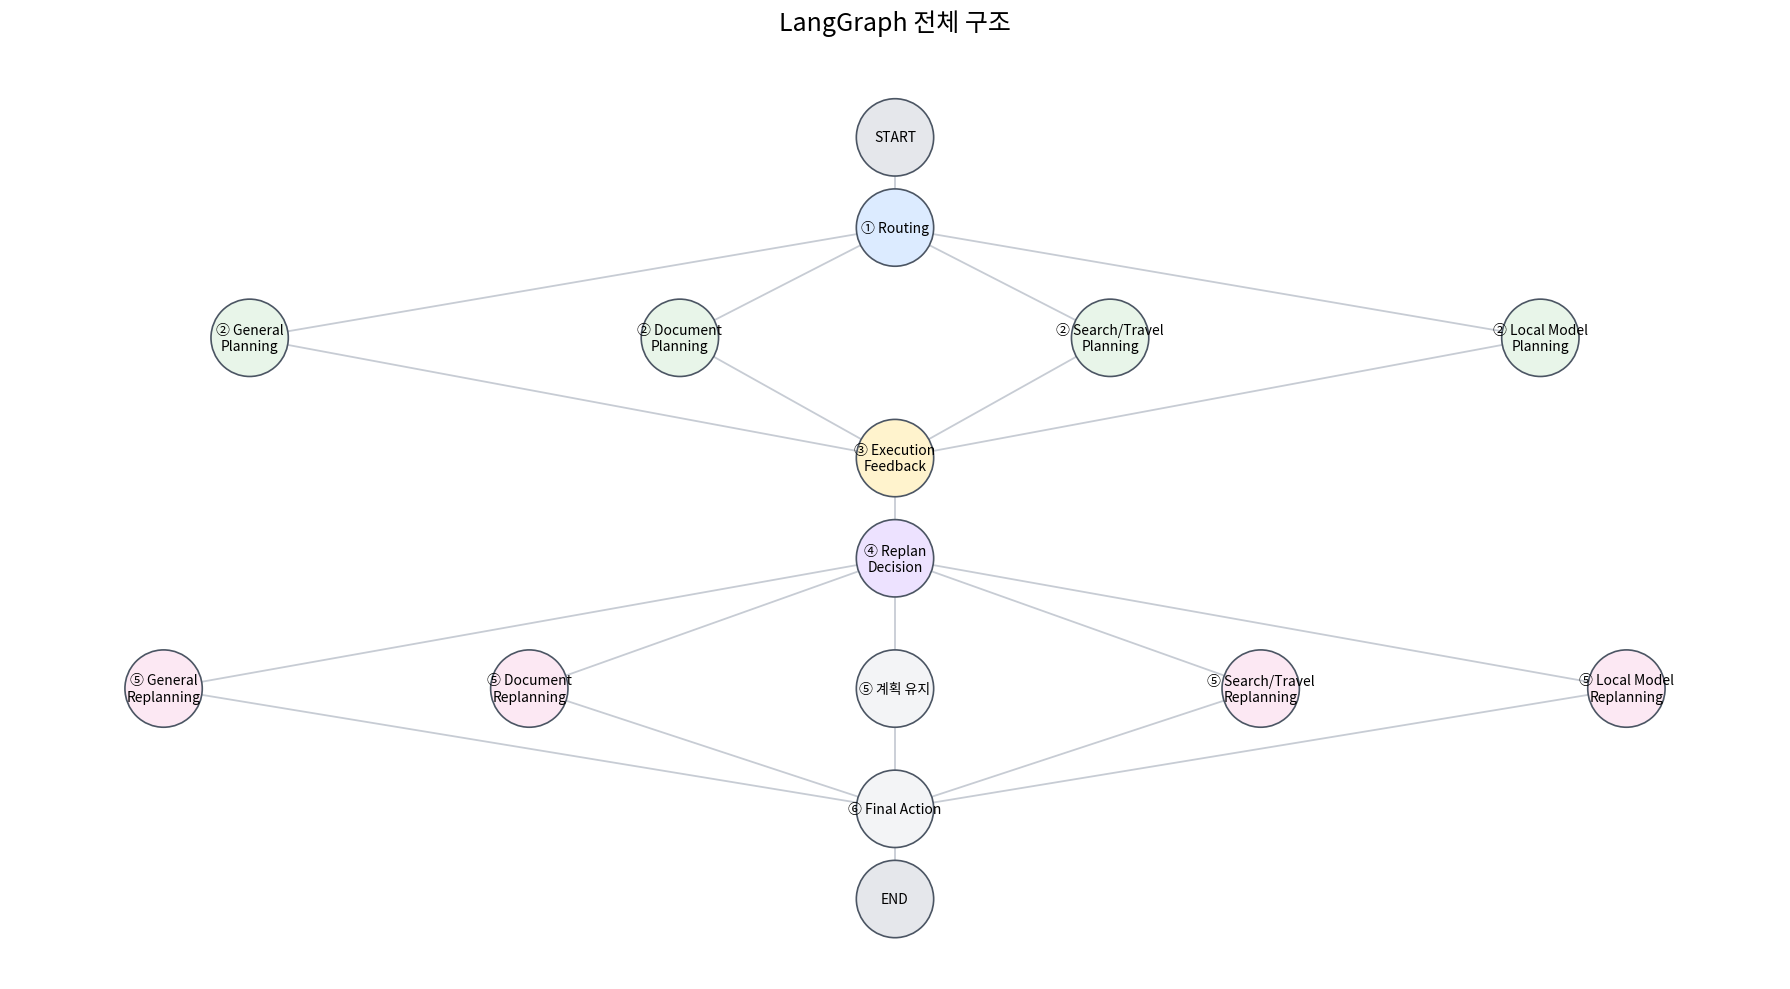

In [15]:
# ============================================================
# 15. 전체 Workflow + 실제 실행 Path 시각화
# ============================================================
ALL_EDGES = [
    ("START", "router"),
    ("router", "plan_general"),
    ("router", "plan_document"),
    ("router", "plan_search_travel"),
    ("router", "plan_local_model"),
    ("plan_general", "execution_feedback"),
    ("plan_document", "execution_feedback"),
    ("plan_search_travel", "execution_feedback"),
    ("plan_local_model", "execution_feedback"),
    ("execution_feedback", "replan_gate"),
    ("replan_gate", "replan_general"),
    ("replan_gate", "replan_document"),
    ("replan_gate", "replan_search_travel"),
    ("replan_gate", "replan_local_model"),
    ("replan_gate", "no_replan"),
    ("replan_general", "finalizer"),
    ("replan_document", "finalizer"),
    ("replan_search_travel", "finalizer"),
    ("replan_local_model", "finalizer"),
    ("no_replan", "finalizer"),
    ("finalizer", "END"),
]

NODE_LABELS = {
    "START": "START",
    "router": "① Routing",
    "plan_general": "② General\nPlanning",
    "plan_document": "② Document\nPlanning",
    "plan_search_travel": "② Search/Travel\nPlanning",
    "plan_local_model": "② Local Model\nPlanning",
    "execution_feedback": "③ Execution\nFeedback",
    "replan_gate": "④ Replan\nDecision",
    "replan_general": "⑤ General\nReplanning",
    "replan_document": "⑤ Document\nReplanning",
    "replan_search_travel": "⑤ Search/Travel\nReplanning",
    "replan_local_model": "⑤ Local Model\nReplanning",
    "no_replan": "⑤ 계획 유지",
    "finalizer": "⑥ Final Action",
    "END": "END",
}

POS = {
    "START": (0, 6.5),
    "router": (0, 5.6),
    "plan_general": (-3.0, 4.5),
    "plan_document": (-1.0, 4.5),
    "plan_search_travel": (1.0, 4.5),
    "plan_local_model": (3.0, 4.5),
    "execution_feedback": (0, 3.3),
    "replan_gate": (0, 2.3),
    "replan_general": (-3.4, 1.0),
    "replan_document": (-1.7, 1.0),
    "no_replan": (0, 1.0),
    "replan_search_travel": (1.7, 1.0),
    "replan_local_model": (3.4, 1.0),
    "finalizer": (0, -0.2),
    "END": (0, -1.1),
}

def draw_workflow(executed_path=None, title="LangGraph 전체 구조"):
    G = nx.DiGraph()
    G.add_edges_from(ALL_EDGES)

    executed_path = executed_path or []

    if executed_path:
        display_path = ["START"] + executed_path + ["END"]
        executed_edges = list(zip(display_path[:-1], display_path[1:]))
        executed_nodes = set(display_path)
    else:
        executed_edges = []
        executed_nodes = set()

    plt.figure(figsize=(18, 10))

    nx.draw_networkx_edges(
        G, POS,
        edge_color="#C7CCD4",
        width=1.3,
        arrows=True,
        arrowsize=18,
    )

    valid_edges = [e for e in executed_edges if G.has_edge(*e)]
    if valid_edges:
        nx.draw_networkx_edges(
            G, POS,
            edgelist=valid_edges,
            edge_color="#E4572E",
            width=4.0,
            arrows=True,
            arrowsize=23,
        )

    node_colors = []
    for node in G.nodes():
        if node in executed_nodes:
            node_colors.append("#FFD8C9")
        elif node in ["START", "END"]:
            node_colors.append("#E5E7EB")
        elif node == "router":
            node_colors.append("#DCEBFF")
        elif node.startswith("plan_"):
            node_colors.append("#E8F5E9")
        elif node == "execution_feedback":
            node_colors.append("#FFF3CD")
        elif node == "replan_gate":
            node_colors.append("#EDE2FF")
        elif node.startswith("replan_"):
            node_colors.append("#FCE8F3")
        else:
            node_colors.append("#F3F4F6")

    nx.draw_networkx_nodes(
        G, POS,
        node_color=node_colors,
        node_size=3100,
        edgecolors="#4B5563",
        linewidths=1.2,
    )

    nx.draw_networkx_labels(
        G, POS,
        labels=NODE_LABELS,
        font_family=plt.rcParams["font.family"],
        font_size=10,
    )

    plt.title(title, fontsize=18, pad=20)
    plt.axis("off")
    plt.tight_layout()
    plt.show()

draw_workflow()

In [16]:
# ============================================================
# 16. 실행 함수
# ============================================================
def run_agent(user_request: str, show_graph=True):
    initial_state: AgentState = {
        "user_request": user_request,
        "path": [],
        "event_log": [],
    }

    result = graph.invoke(initial_state)

    print("=" * 90)
    print("USER REQUEST")
    print(user_request.strip())

    print("\n[1] ROUTING")
    print("selected_strategy :", result["selected_strategy"])
    print("executed_model    :", result["executed_model"])

    print("\n[2] INITIAL PLAN")
    for i, step in enumerate(result["initial_plan"], 1):
        print(f"  {i}. {step}")

    print("\n[3] EXECUTION FEEDBACK")
    print(" ", result["execution_feedback"])

    print("\n[4] REPLANNING")
    print("need_replan =", result["need_replan"])
    for i, step in enumerate(result["revised_plan"], 1):
        marker = "🔄" if result["need_replan"] else "✅"
        print(f"  {marker} {i}. {step}")

    print("\n[5] ACTUAL LANGGRAPH PATH")
    print(" → ".join(result["path"]))

    print("\n[6] EVENT LOG")
    display(pd.DataFrame(result["event_log"]))

    if show_graph:
        draw_workflow(
            executed_path=result["path"],
            title=f"실제 실행 경로 — {result['selected_strategy']} strategy",
        )

    return result

# 17. 네 가지 Strategy Case 실행

각 Case는 서로 다른 Routing 전략이 선택되도록 구성

1. **General Strategy** — 일반 업무 + 예산 제약
2. **Document Strategy** — 긴 정책 문서 + 요구사항 충돌
3. **Search/Travel Strategy** — 지도/검색 기반 여행
4. **Local Model Strategy** — 로컬 오픈소스 모델 + GPU 제약


USER REQUEST
신규 AI 교육 프로젝트를 4주 안에 준비하려고 한다.
강의안, 실습 코드, 평가 기준을 포함한 계획을 만들어 줘.
전체 외부 서비스 비용은 30만원을 넘으면 안 된다.

[1] ROUTING
selected_strategy : general
executed_model    : openai

[2] INITIAL PLAN
  1. 1주차: 교육 목표와 대상 수준을 확정하고, 4주 내 제공 범위를 정의한다. 동시에 강의안 목차(예: AI 기초, 프롬프트 설계, 실습, 사례 적용, 윤리/한계)와 최종 산출물 형식을 설계한다.
  2. 2주차: 강의안 초안을 작성하고, 실습 코드의 개발 환경을 결정한다. 외부 서비스는 무료/저비용 도구 위주로 선택하고, 유료 API 사용이 필요하면 예산 상한 내에서 최소 호출량으로 제한한다.
  3. 3주차: 실습 코드와 예제 데이터를 구현하고, 각 강의별 실습 과제를 연결한다. 동시에 평가 기준(참여도, 실습 완성도, 결과 정확성, 설명 능력)을 점수화하여 루브릭 형태로 정리한다.
  4. 4주차: 전체 강의안, 실습 코드, 평가 기준을 통합해 리허설/검수한다. 오류 수정, 일정 조정, 비용 점검을 완료하고 외부 서비스 총비용이 30만원 이하인지 최종 확인한 뒤 배포본으로 정리한다.

[3] EXECUTION FEEDBACK
  최초 계획을 그대로 실행할 경우 예상 비용이 사용자의 예산을 초과합니다. 비용 제약을 만족하도록 계획을 수정해야 합니다.

[4] REPLANNING
need_replan = True
  🔄 1. 1주차: 교육 목표와 대상 수준을 확정하고, 4주 내 제공 범위를 다시 좁혀 예산 우선순위를 반영한다. 강의안 목차와 최종 산출물 형식을 설계하되, 외부 서비스는 기본적으로 로컬 실행/오픈소스 도구 중심으로 제한한다.
  🔄 2. 2주차: 강의안 초안을 작성하고, 실습 코드는 무료 또는 자체 실행 가능한 환경으로 개발한다. 유료 API나 외부 서비스가 꼭 필요한 부분은 대체안으로 변경하고,

,step,node,stage,provider,detail
0,1,router,Routing,openai,요청 특성을 분석하여 general 전략 선택
1,2,plan_general,Planning,openai,general 전략으로 최초 계획 4단계 생성
2,3,execution_feedback,Execution / Observation,openai,최초 계획을 그대로 실행할 경우 예상 비용이 사용자의 예산을 초과합니다. 비용 제약...
3,4,replan_gate,Replanning Decision,openai,기존 계획이 더 이상 유효하지 않음 → Replanning 수행
4,5,replan_general,Replanning,openai,예상 비용 초과 원인을 반영해 유료 외부 서비스 의존도를 줄이고 로컬·무료 도구 중...
5,6,finalizer,Final Action,openai,실행 피드백을 반영하여 수정된 계획을 최종 계획으로 채택


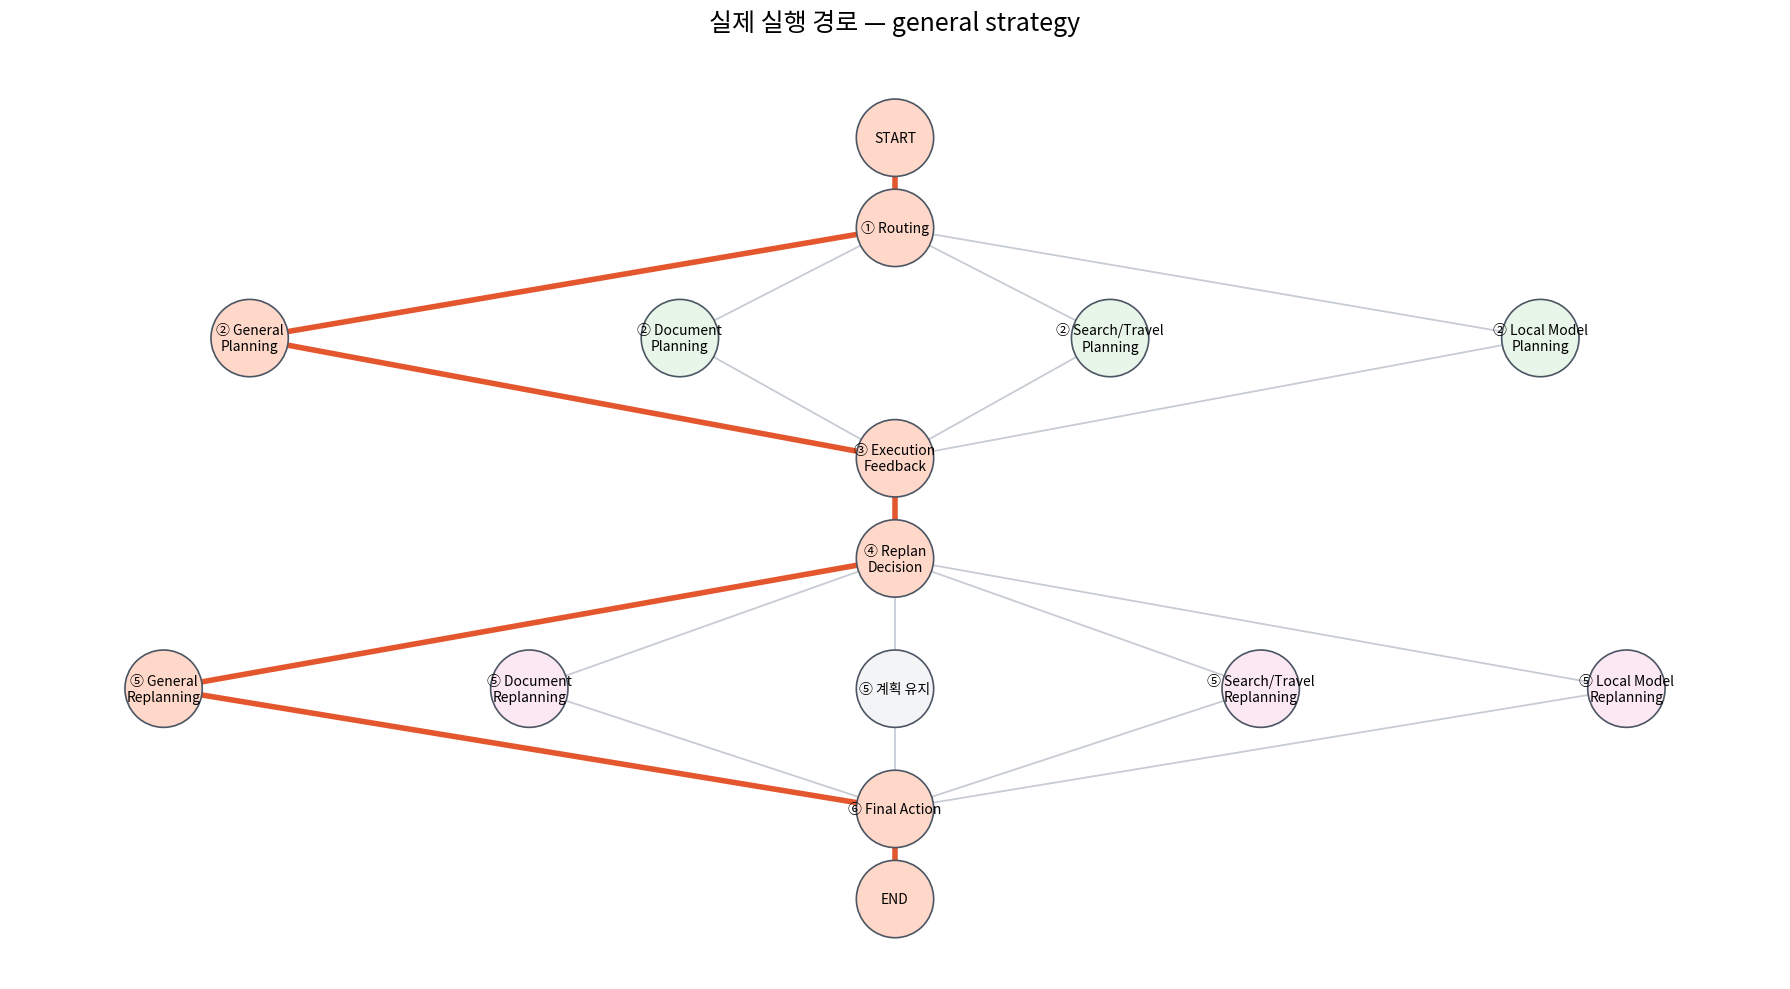

In [17]:
# Case A — OpenAI
case_openai = """
신규 AI 교육 프로젝트를 4주 안에 준비하려고 한다.
강의안, 실습 코드, 평가 기준을 포함한 계획을 만들어 줘.
전체 외부 서비스 비용은 30만원을 넘으면 안 된다.
"""

result_openai = run_agent(case_openai)

USER REQUEST
긴 정책 문서와 여러 부서의 요구사항을 검토해서
AI 거버넌스 도입 계획을 수립하려고 한다.
정책 간 충돌과 요구사항 우선순위를 고려해서 계획해 줘.

[1] ROUTING
selected_strategy : document
executed_model    : openai

[2] INITIAL PLAN
  1. 1단계: 관련 정책 문서와 각 부서 요구사항을 수집·정리하고, 적용 범위·의무사항·예외조건을 기준으로 항목별로 분해한다.
  2. 2단계: 정책 간 충돌 가능성과 상충되는 부서 요구사항을 식별한 뒤, 법규 준수·보안·리스크 최소화 기준으로 우선순위를 설정한다.
  3. 3단계: 우선순위가 정해진 요구사항을 바탕으로 AI 거버넌스 원칙, 역할과 책임, 승인 절차, 통제 기준을 초안화한다.
  4. 4단계: 부서별 영향도와 실행 가능성을 검토하여 단계적 도입 로드맵, 예외 처리 기준, 운영 지표를 포함한 최종 계획으로 정리한다.

[3] EXECUTION FEEDBACK
  문서 검토 중 핵심 요구사항 하나가 최초 계획의 가정과 충돌하는 것이 발견되었습니다. 요구사항 우선순위와 검토 순서를 수정해야 합니다.

[4] REPLANNING
need_replan = True
  🔄 1. 1단계: 문서 검토 전에 핵심 충돌 요구사항을 먼저 식별하고, 법규 준수·보안·필수 운영조건처럼 선행 검토가 필요한 기준을 우선 적용해 검토 순서를 재설정한다.
  🔄 2. 2단계: 관련 정책 문서와 각 부서 요구사항을 수집·정리하되, 적용 범위·의무사항·예외조건뿐 아니라 새로 발견된 충돌 요구사항과의 적합성까지 함께 항목별로 분해한다.
  🔄 3. 3단계: 정책 간 충돌과 상충되는 부서 요구사항을 비교·조정하고, 우선순위를 재산정한 뒤 AI 거버넌스 원칙, 역할과 책임, 승인 절차, 통제 기준의 초안을 작성한다.
  🔄 4. 4단계: 부서별 영향도와 실행 가능성을 다시 검토하여 단계적 도입 로드맵, 예외 처리 기준, 운영 지표를 포함한 최종 계획으로 정

,step,node,stage,provider,detail
0,1,router,Routing,openai,요청 특성을 분석하여 document 전략 선택
1,2,plan_document,Planning,openai,document 전략으로 최초 계획 4단계 생성
2,3,execution_feedback,Execution / Observation,openai,문서 검토 중 핵심 요구사항 하나가 최초 계획의 가정과 충돌하는 것이 발견되었습니다...
3,4,replan_gate,Replanning Decision,openai,기존 계획이 더 이상 유효하지 않음 → Replanning 수행
4,5,replan_document,Replanning,openai,"핵심 요구사항이 최초 가정과 충돌해 검토 순서를 선행 충돌 식별 중심으로 바꾸고, ..."
5,6,finalizer,Final Action,openai,실행 피드백을 반영하여 수정된 계획을 최종 계획으로 채택


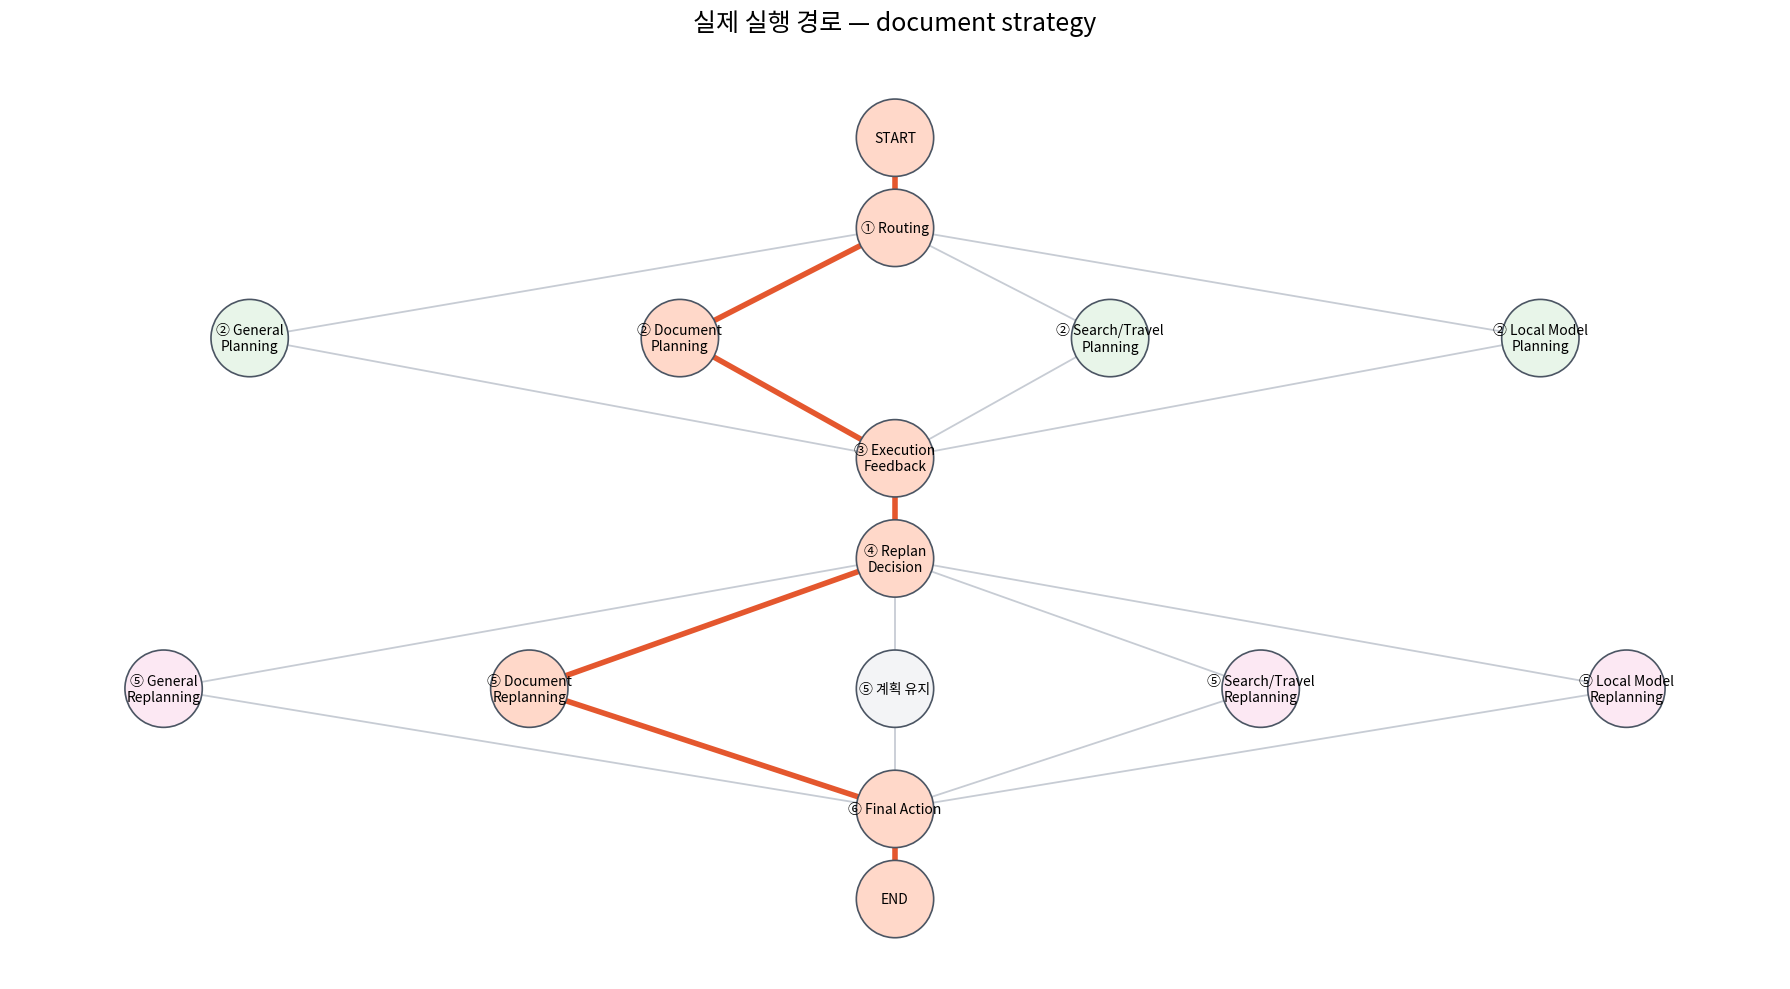

In [18]:
# Case B — Claude
case_claude = """
긴 정책 문서와 여러 부서의 요구사항을 검토해서
AI 거버넌스 도입 계획을 수립하려고 한다.
정책 간 충돌과 요구사항 우선순위를 고려해서 계획해 줘.
"""

result_claude = run_agent(case_claude)

USER REQUEST
구글 지도와 검색 정보를 활용해서
서울에서 하루 동안 이동 동선이 짧은 AI 관련 장소 방문 일정을 계획해 줘.

[1] ROUTING
selected_strategy : search_travel
executed_model    : openai

[2] INITIAL PLAN
  1. 1단계: 구글 지도에서 서울 내 AI 관련 장소 후보를 먼저 수집한다. 예: AI 연구/교육 기관, AI 전시·체험 공간, 스타트업 허브, 관련 컨퍼런스/전시가 열리는 장소를 검색하고, 각 장소의 위치·운영시간·입장 조건을 확인한다.
  2. 2단계: 검색 정보를 함께 확인해 같은 권역에 몰려 있는 장소를 추린다. 이동 동선이 짧도록 강남/역삼, 여의도, 마곡, 종로·광화문 등 후보 권역별로 묶고, 당일 방문 가능한 곳만 선별한다.
  3. 3단계: 구글 지도에서 도보/대중교통 이동 시간을 비교해 최종 동선을 짠다. 첫 방문지에서 두 번째, 세 번째 장소까지의 예상 소요시간과 영업 종료 시간을 기준으로 순서를 조정한다.
  4. 4단계: 최종 일정에 대해 각 장소의 최신 정보가 맞는지 다시 확인한다. 휴무, 예약 필요 여부, 행사 일정 변동, 입장 제한 등을 검색으로 점검한 뒤 하루 일정으로 확정한다.

[3] EXECUTION FEEDBACK
  실행 중 확인 결과 첫 번째 후보 장소가 해당 시간에 운영하지 않는 것으로 확인되었습니다. 대체 장소와 이동 순서를 다시 계획해야 합니다.

[4] REPLANNING
need_replan = True
  🔄 1. 1단계: 구글 지도와 검색 정보로 서울 내 AI 관련 장소 후보를 다시 수집하되, 이번에는 운영 시간·휴무 여부를 우선 확인해 첫 번째 후보가 운영하지 않는 시간대를 피할 수 있는 대체 장소를 함께 확보한다.
  🔄 2. 2단계: 같은 권역에 있는 후보들을 강남/역삼, 여의도, 마곡, 종로·광화문 등으로 묶어 재분류하고, 당일 방문 가능한 장소만 남겨 첫 방문지의 대체 순서를 먼저 정한다.
  🔄 3.

,step,node,stage,provider,detail
0,1,router,Routing,openai,요청 특성을 분석하여 search_travel 전략 선택
1,2,plan_search_travel,Planning,openai,search_travel 전략으로 최초 계획 4단계 생성
2,3,execution_feedback,Execution / Observation,openai,실행 중 확인 결과 첫 번째 후보 장소가 해당 시간에 운영하지 않는 것으로 확인되었...
3,4,replan_gate,Replanning Decision,openai,기존 계획이 더 이상 유효하지 않음 → Replanning 수행
4,5,replan_search_travel,Replanning,openai,"첫 번째 후보가 해당 시간에 운영하지 않는 것으로 확인되어, 운영 시간 확인을 우선..."
5,6,finalizer,Final Action,openai,실행 피드백을 반영하여 수정된 계획을 최종 계획으로 채택


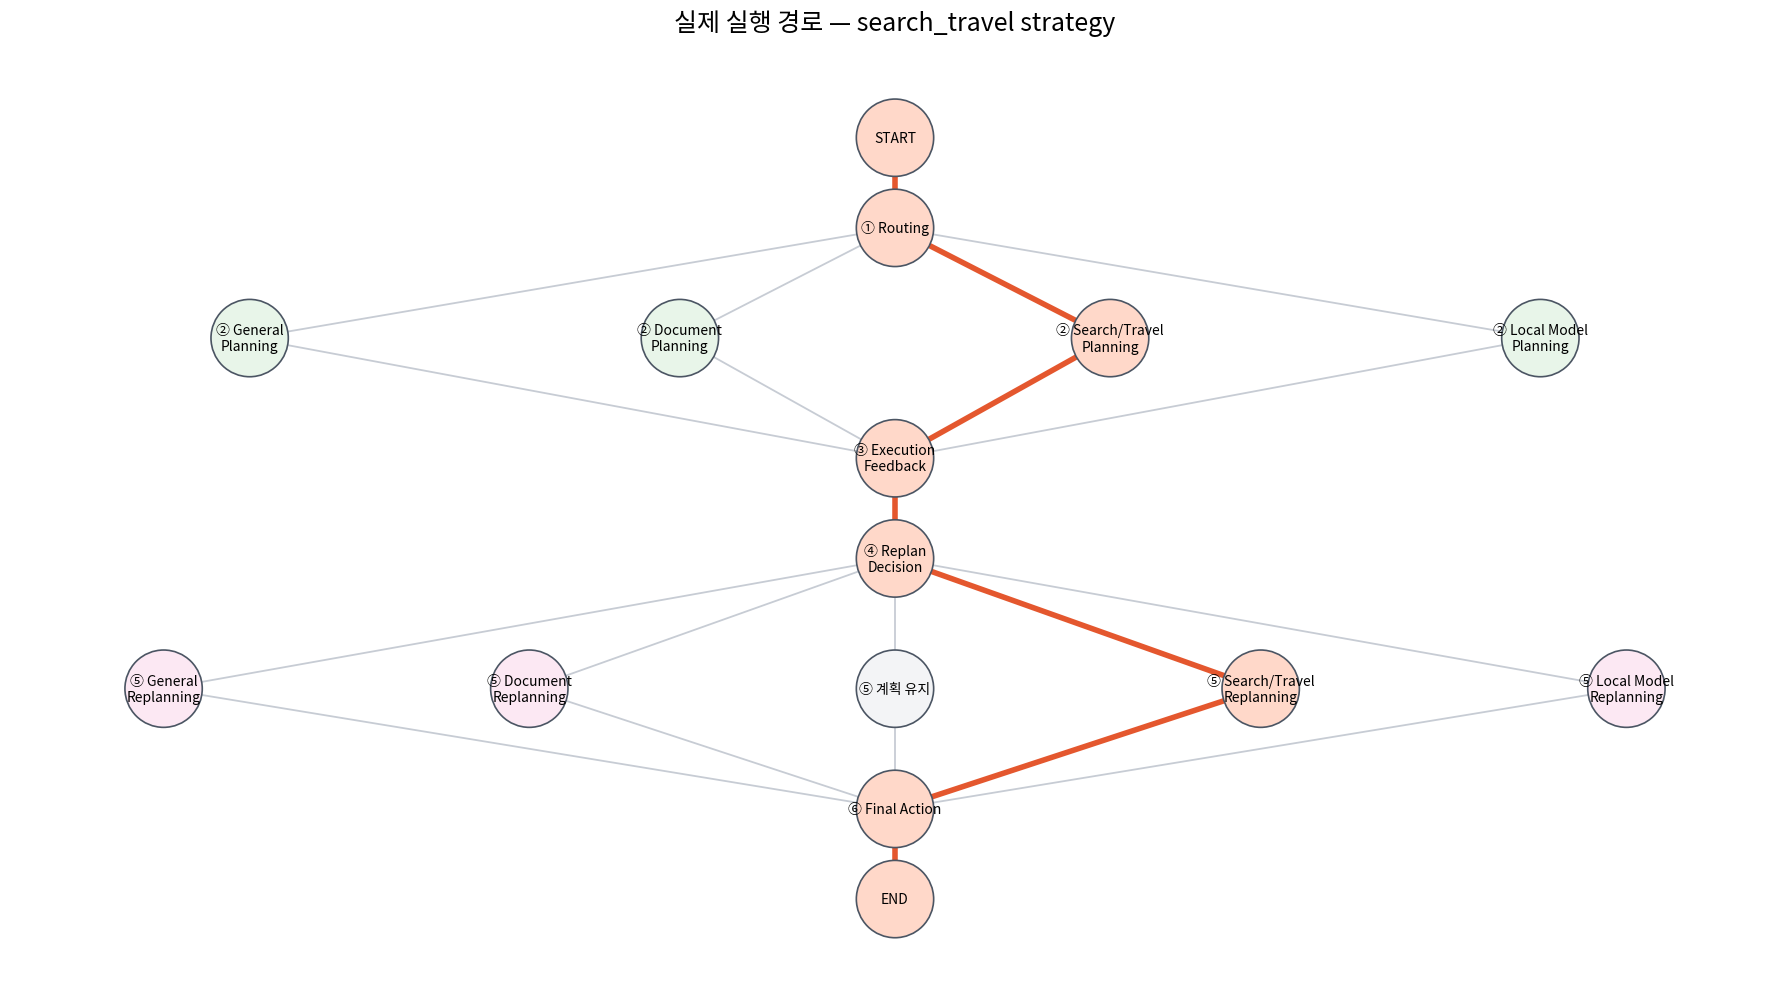

In [19]:
# Case C — Google
case_google = """
구글 지도와 검색 정보를 활용해서
서울에서 하루 동안 이동 동선이 짧은 AI 관련 장소 방문 일정을 계획해 줘.
"""

result_google = run_agent(case_google)

USER REQUEST
허깅페이스의 오픈소스 모델을 사용해서
16GB GPU 한 대에서 실행할 수 있는 로컬 문서 요약 에이전트를 만들고 싶다.
모델 선정부터 실행까지 계획해 줘.

[1] ROUTING
selected_strategy : local_model
executed_model    : openai

[2] INITIAL PLAN
  1. 1단계: 요구사항 확정 — 16GB 단일 GPU에서 동작해야 하므로, 문서 요약은 '단일 문서 입력 → 요약 출력' 중심으로 설계한다. 실행 환경은 로컬 Python + PyTorch + Hugging Face Transformers 기준으로 잡고, 상용/재배포 가능 여부를 확인할 수 있는 Apache-2.0, MIT, BSD 계열 라이선스 우선으로 모델 후보를 제한한다.
  2. 2단계: 모델 선정 — 16GB GPU에 맞는 7B 이하급 요약/생성 모델을 우선 검토한다. 예: FLAN-T5 계열(요약에 강점, 상대적으로 가벼움), BART/PEGASUS 계열(전통적 요약 성능), 또는 Llama/Mistral 계열의 소형 Instruct 모델을 4bit 양자화로 사용하는 방법을 비교한다. 문서 길이가 길다면 긴 컨텍스트 지원 모델 또는 청크 요약 방식도 함께 고려한다.
  3. 3단계: 로컬 실행 방식 결정 — Transformers + bitsandbytes 4bit/8bit 양자화로 VRAM 사용량을 줄이고, 필요 시 CPU offload를 허용한다. 긴 문서는 텍스트 분할기(text splitter)로 청크를 나눈 뒤 부분 요약을 합치는 map-reduce 방식으로 구현한다. 문서 입력은 PDF/DOCX/TXT 파서로 통합하고, 프롬프트 템플릿을 고정해 일관된 요약 품질을 확보한다.
  4. 4단계: 에이전트 구현 — '문서 로딩 → 전처리 → 청크 분할 → 요약 → 최종 정리' 파이프라인으로 구성한다. LangChain 또는 LlamaIndex 같은 오케스트레이션 프레임워크를 사용하되, 실제 추론은 Hugg

,step,node,stage,provider,detail
0,1,router,Routing,openai,요청 특성을 분석하여 local_model 전략 선택
1,2,plan_local_model,Planning,openai,local_model 전략으로 최초 계획 5단계 생성
2,3,execution_feedback,Execution / Observation,openai,실행 환경의 GPU 메모리가 예상보다 작아 최초 선정 모델을 로드할 수 없습니다. ...
3,4,replan_gate,Replanning Decision,openai,기존 계획이 더 이상 유효하지 않음 → Replanning 수행
4,5,replan_local_model,Replanning,openai,"GPU 메모리가 예상보다 작아 7B급 후보를 그대로 쓰지 않고, 더 작은 모델과 더..."
5,6,finalizer,Final Action,openai,실행 피드백을 반영하여 수정된 계획을 최종 계획으로 채택


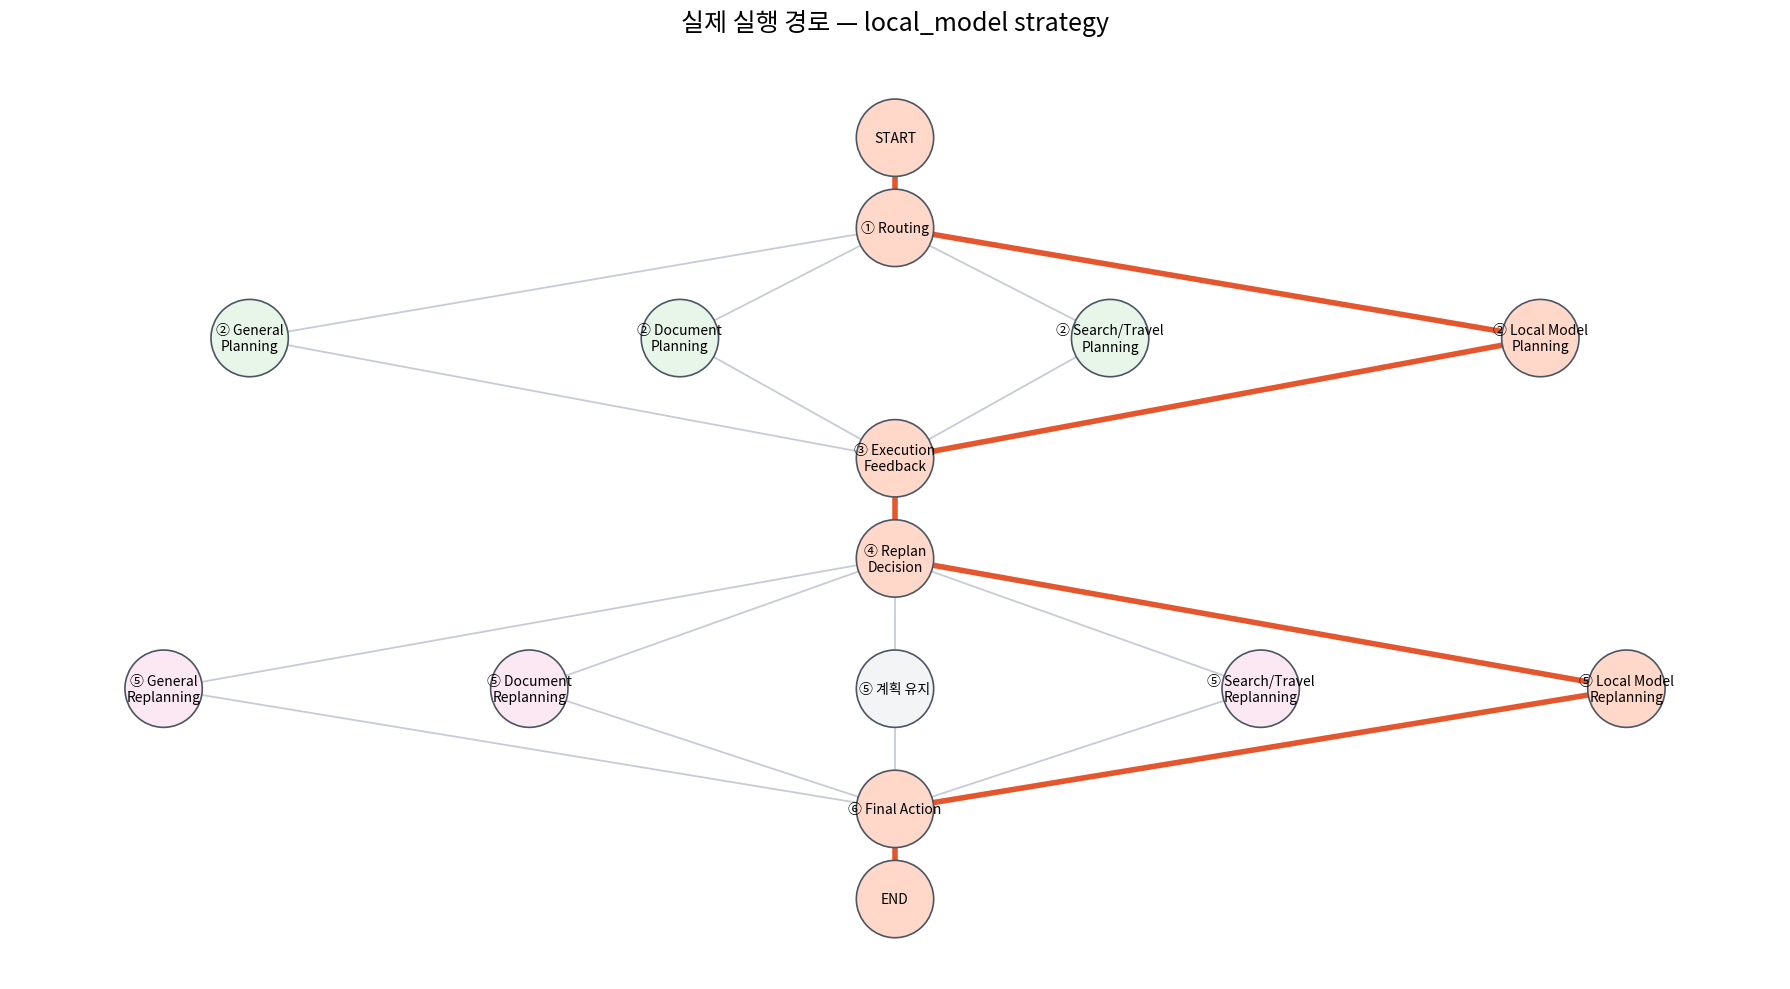

In [20]:
# Case D — Hugging Face
case_hf = """
허깅페이스의 오픈소스 모델을 사용해서
16GB GPU 한 대에서 실행할 수 있는 로컬 문서 요약 에이전트를 만들고 싶다.
모델 선정부터 실행까지 계획해 줘.
"""

result_hf = run_agent(case_hf)

In [21]:
# ============================================================
# 18. 네 가지 실행 결과 비교
# ============================================================
results = {
    "General case": result_openai,
    "Document case": result_claude,
    "Search/Travel case": result_google,
    "Local Model case": result_hf,
}

rows = []

for name, r in results.items():
    rows.append({
        "case": name,
        "selected_strategy": r["selected_strategy"],
        "executed_model": r["executed_model"],
        "need_replan": r["need_replan"],
        "initial_steps": len(r["initial_plan"]),
        "revised_steps": len(r["revised_plan"]),
        "executed_path": " → ".join(r["path"]),
    })

summary_df = pd.DataFrame(rows)
display(summary_df)

,case,selected_strategy,executed_model,need_replan,initial_steps,revised_steps,executed_path
0,General case,general,openai,True,4,4,router → plan_general → execution_feedback → r...
1,Document case,document,openai,True,4,4,router → plan_document → execution_feedback → ...
2,Search/Travel case,search_travel,openai,True,4,4,router → plan_search_travel → execution_feedba...
3,Local Model case,local_model,openai,True,5,5,router → plan_local_model → execution_feedback...


# 19.  **모델은 하나(OpenAI)지만, Routing Strategy는 여러 개일 수 있음**

```text
Same OpenAI LLM
      ↓
Different Routing Strategy
      ↓
Different Planning Prompt
      ↓
Execution Feedback
      ↓
Different Replanning Prompt
```

### Planning
현재 알고 있는 Goal / State / Constraint를 기준으로 최초 실행 경로를 설계

### Replanning
실행 후 새롭게 관찰된 정보 때문에 기존 계획이 더 이상 적절하지 않을 때,
기존 계획 + 새로운 Observation/State/Constraint를 바탕으로 계획을 수정

### 노드 매핑

| 개념 | 노드 |
|---|---|
| Routing | `router` |
| Planning | `plan_general`, `plan_document`, `plan_search_travel`, `plan_local_model` |
| Observation | `execution_feedback` |
| Replanning 판단 | `replan_gate` |
| Replanning | `replan_general`, `replan_document`, `replan_search_travel`, `replan_local_model` |
| Final Action | `finalizer` |